In [1]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [2]:
train = pd.read_csv('train.csv')    
test = pd.read_csv('test.csv')  
submission = pd.read_csv('sample_submission.csv')

* ### EDA
Om de data goed te kunnen gebruiken moet het voldoen aan wat voorwaarden zodat we het kunnen verwerken met Scikit Learn. In de onderstaande code word gekeken of er aan deze voorwaarden voldaan wordt. Zo wordt er gekeken naar of er ontbrekende of dubbele waarden zijn, of het numerieke waarden zijn en wat de form van de dataset is.

In [3]:
display(train.head())
display(test.head())
display(submission.head())

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes,stroke
0,52709,30.0,0,0,63.60,33.3,False,True,False,True,...,False,True,False,False,True,False,False,False,True,0
1,72295,75.0,1,0,215.17,48.0,True,False,False,False,...,False,False,True,False,True,False,False,True,False,0
2,26451,15.0,0,0,135.22,19.0,False,True,False,True,...,False,True,False,False,True,False,False,True,False,0
3,65210,47.0,0,0,64.89,28.2,False,True,False,False,...,False,False,True,False,False,True,False,True,False,0
4,69299,49.0,0,0,222.34,28.8,False,True,False,False,...,False,False,True,False,True,False,True,False,False,0


,id,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Female,gender_Male,gender_Other,ever_married_No,...,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,32840,52.0,0,0,97.32,21.8,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
1,45158,30.0,0,0,227.99,47.7,True,False,False,False,...,False,False,True,False,False,False,True,False,False,True
2,56105,26.0,0,0,113.28,24.4,True,False,False,False,...,False,False,True,False,False,False,True,False,True,False
3,3112,24.0,0,0,79.15,21.0,True,False,False,False,...,False,False,True,False,False,False,True,True,False,False
4,35224,63.0,0,0,89.69,33.3,True,False,False,False,...,False,False,True,False,False,False,True,False,True,False


,id,stroke
0,32840,1
1,45158,0
2,56105,1
3,3112,0
4,35224,1


In [4]:
def VoldoetDf(df, naam):

    print(f"Analyse van DataFrame: {naam}")

    # Controleren op missende waarden
    missende_waarden = df.isnull().sum()
    if sum(missende_waarden) > 0:
            print(f'Er zijn {sum(missende_waarden)} missende waarden')
    else:
        print('Er zijn geen missende waarden')

    # Controleren op dubbele rijen
    dubbele_rijen = df.duplicated().sum()
    if dubbele_rijen > 0:
        print(f'Er zijn {dubbele_rijen} dubbele rijen')
    else:
        print('Er zijn geen dubbele rijen')

    # Controleer de datatypes van de kolommen
    data_types = df.dtypes
    print("Data types:", data_types.unique())

    # Controleer de vorm van de DataFrame
    print(f'De DataFrame heeft {df.shape[0]} rijen en {df.shape[1]} kolommen')

    # Witregel voor betere leesbaarheid
    print()
    
VoldoetDf(train, 'train')
VoldoetDf(test, 'test')
VoldoetDf(submission, 'submission')


Analyse van DataFrame: train
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 33550 rijen en 22 kolommen

Analyse van DataFrame: test
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 8388 rijen en 21 kolommen

Analyse van DataFrame: submission
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64')]
De DataFrame heeft 8388 rijen en 2 kolommen



De data voldoet aan alle eisen van Scikit Learn. Er zijn namelijk geen missende waarden, alle data is numeriek (of een boolean) en de testset en de datasets zijn tweedimensionaal. De testset en de submission set zijn ook even groot en zouden dus geen problemen moeten opleveren.

Toon de datatypes en basisstatistieken van iedere kolom.

In [5]:
display(train.describe(), train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


None

We onderzoeken de relatie tussen onze features onderling en de relatie met onze target. Hiermee kunnen we voorkomen dat er multicollineariteit optreed in ons model. In de onderstaande cel kijken we welke features een hoge correlatie met elkaar hebben.

In [6]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")


age - ever_married_No: -0.69
age - ever_married_Yes: 0.69
age - work_type_children: -0.64
gender_Female - gender_Male: -1.00
ever_married_No - ever_married_Yes: -1.00
ever_married_No - work_type_children: 0.55
ever_married_Yes - work_type_children: -0.55
Residence_type_Rural - Residence_type_Urban: -1.00


We zien dat sommige features een perfecte correlatie hebben en dat is heel logisch. De features zijn dummy kolommen en zijn uit de kolom voortgekomen. Om dit op te lossen kunnen we simpelweg 1 van de dummy kolommen verwijderen.

In [7]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']

# drop dummykolommen met errors= ignore zodat de codecel geen error krijgt na twee keer runnen
train = train.drop(columns=drop_columns, errors= "ignore")
test = test.drop(columns=drop_columns, errors= "ignore")

Als we nu kijken welke features nog een hoge correlatie hebben zien we dat het er een stuk minder zijn.

In [8]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")

age - ever_married_Yes: 0.69
age - work_type_children: -0.64
ever_married_Yes - work_type_children: -0.55


De correlatie tussen deze features is nog niet hoog genoeg om voor multicollineariteit te zorgen, omdat daar een sterke correlatie van minstens 0.7 voor nodig is.

We zien dat de features geen grote correlatie hebben met de target. Dit betekent dat ons model naar alle features zal moeten gaan kijken om een goede voorspelling te kunnen maken.

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die een hoge correlatie hebben met onze target, dus we zullen naar alle features moeten gaan kijken.

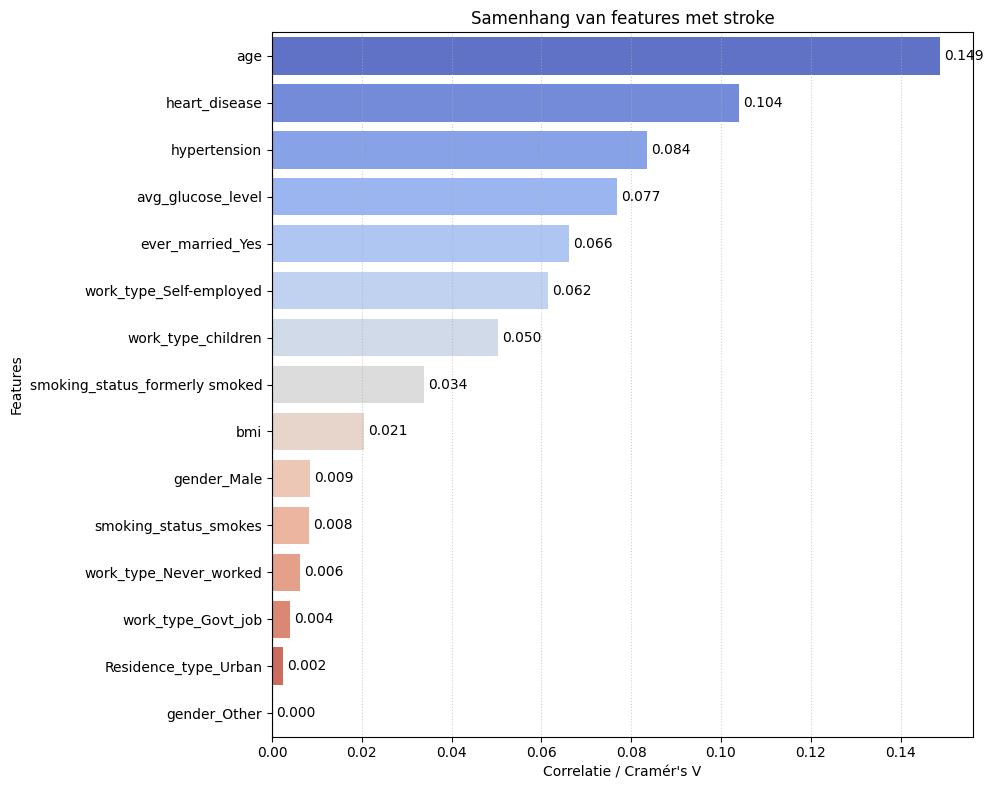

In [9]:
target_col = 'stroke'


# ---------------------------------------------------
# 1. Kolommen opdelen
# ---------------------------------------------------

numerical_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

categorical_cols = [
    'heart_disease',
    'hypertension',
    'ever_married_Yes',
    'work_type_Self-employed',
    'smoking_status_formerly smoked',
    'gender_Male',
    'smoking_status_smokes',
    'Residence_type_Urban',
    'gender_Other',
    'work_type_Govt_job',
    'work_type_Never_worked',
    'work_type_children'
]


# ---------------------------------------------------
# 2. Functie voor Cramér's V
# ---------------------------------------------------

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))


# ---------------------------------------------------
# 3. Point-biserial correlatie voor numerieke features
# ---------------------------------------------------

numerical_correlations = {}

for col in numerical_cols:

    # Alleen rijen gebruiken zonder missende waarden
    temp = train[[col, target_col]].dropna()

    corr, p_value = pointbiserialr(
        temp[target_col],
        temp[col]
    )

    numerical_correlations[col] = corr


# ---------------------------------------------------
# 4. Cramér's V voor categorische features
# ---------------------------------------------------

categorical_correlations = {}

for col in categorical_cols:

    temp = train[[col, target_col]].dropna()

    corr = cramers_v(
        temp[col],
        temp[target_col]
    )

    categorical_correlations[col] = corr


# ---------------------------------------------------
# 5. Alles samenvoegen
# ---------------------------------------------------

correlations = {
    **numerical_correlations,
    **categorical_correlations
}

correlations = pd.Series(correlations)

# Sorteren van hoogste naar laagste
correlations = correlations.sort_values(ascending=False)


# ---------------------------------------------------
# 6. Grafiek maken
# ---------------------------------------------------

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    legend=False,
    palette='coolwarm'
)

# Waarde achter iedere balk zetten
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )


plt.title('Samenhang van features met stroke')
plt.xlabel('Correlatie / Cramér\'s V')
plt.ylabel('Features')

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=0.8
)

plt.grid(
    axis='x',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken. Gender_other heeft een correlatie van 0.000, dus deze kan weggehaald worden.

In [10]:
# onbelangrijke kolommen verwijderen op basis van eerder berekende correlatie met target
train = train.drop(columns=["gender_Other", "id"], errors="ignore")
test = test.drop(columns=["gender_Other", "id"], errors="ignore")

### Standaardiseren
In veel gevallen ligt niet alle data op dezelfde schaal. Bijvoorbeeld in de dataset uit deze opdracht heeft een kolom zoals "heart_disease" een waarde van 0 of 1, maar age kan bijvoorbeeld 70 zijn. Bij de meeste ML modellen zal age dan veel meer invloed hebben op de voorspelling, omdat de waarde zo veel hoger ligt. Maar allebei de features hebben invloed op de voorspelling, dus wat doen we dan? In dit geval gaan wij standaardiseren. Bij standaardiseren worden alle features op dezelfde schaal gebracht. Als wij kijken naar de kolommen in de train- en testset, moet standaardisatie zeker toegepast worden. Dit wordt in de code cel hieronder toegepast:

In [11]:
# train validation set aanmaken
X = train.drop(columns=["stroke"])
y = train["stroke"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train = X_train.copy()
X_val = X_val.copy()

# bool kolommen naar integer
bool_cols_train = X_train.select_dtypes(include="bool").columns
bool_cols_val = X_val.select_dtypes(include="bool").columns

X_train[bool_cols_train] = X_train[bool_cols_train].astype(int)
X_val[bool_cols_val] = X_val[bool_cols_val].astype(int)

# numerieke kolommen scalen
scaler = StandardScaler()
num_cols = X_train.select_dtypes(include="number").columns

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# 2
### Metrics
Metrics zijn functies die worden gebruikt om de prestatie van je model te beoordelen. Deze worden meestal gebruikt op de testset. In deze dataset moeten wij een klasse voorspellen **(0 is geen stroke, 1 is wel een stroke)**. Metrics die wij bij dit classificatieprobleem kunnen gebruiken zijn:

**Accuracy:** Hoeveel van de totale voorspellingen zijn correct voorspeld door het model?

**Recall:** Hoeveel van de positieve gevallen zijn door het model gevonden?

**Precision:** Hoeveel van de positieve voorspellingen zijn correct?

**F1-score:** Een combinatie tussen Recall en Precision



### test set klaarmaken:

In [12]:
#drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']

#test = test.drop(columns=drop_columns)
#test = test.drop(columns=["gender_Other", "id"])

#X_test = test.copy()
#y_test = submission.drop(columns=["id"])

#bool_kolommen = X_test.select_dtypes(include="bool").columns

#X_test[bool_kolommen] = X_test[bool_kolommen].astype(int)
#numerieke_kolommen = X_test.select_dtypes(include="number").columns
#X_test[numerieke_kolommen] = scaler.transform(X_test[numerieke_kolommen])

#display(X_test.head())
#display(y_test.head())

### Uitvoeren model:

In [13]:

# SVC model
svc_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",  # handig als je binaire klassen ongelijk verdeeld zijn
    random_state=42
)

# Model trainen
svc_model.fit(X_train, y_train)

y_val_pred = svc_model.predict(X_val)
print("Validation accuracy:", accuracy_score(y_val, y_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, y_val_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_val_pred))

Validation accuracy: 0.809538002980626

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.81      0.89      6607
           1       0.04      0.50      0.08       103

    accuracy                           0.81      6710
   macro avg       0.52      0.66      0.48      6710
weighted avg       0.98      0.81      0.88      6710


Confusion Matrix:
[[5380 1227]
 [  51   52]]


In [14]:
X_full = train.drop(columns=["stroke"]).copy()
y_full = train["stroke"].copy()

X_full = X_full.copy()
bool_cols_full = X_full.select_dtypes(include="bool").columns
X_full[bool_cols_full] = X_full[bool_cols_full].astype(int)
num_cols_full = X_full.select_dtypes(include="number").columns

scaler_final = StandardScaler()
X_full[num_cols_full] = scaler_final.fit_transform(X_full[num_cols_full])

X_test = test.copy()
if "id" in X_test.columns:
    test_ids = X_test["id"].copy()
    X_test = X_test.drop(columns=["id"])
else:
    test_ids = None

X_test = X_test.copy()
bool_cols_test = X_test.select_dtypes(include="bool").columns
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)
num_cols_test = X_test.select_dtypes(include="number").columns
X_test[num_cols_test] = scaler_final.transform(X_test[num_cols_test])

svc_final = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)
svc_final.fit(X_full, y_full)

final_pred = svc_final.predict(X_test)

# Optional: submission dataframe
if test_ids is not None:
    submission_out = pd.DataFrame({"id": test_ids, "stroke": final_pred})
    display(submission_out.head())

In [15]:
final_val_pred = svc_final.predict(X_val)
print("Final model validation accuracy:", accuracy_score(y_val, final_val_pred))
print("\nClassification Report:")
print(classification_report(y_val, final_val_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, final_val_pred))

Final model validation accuracy: 0.8068554396423249

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.81      0.89      6607
           1       0.07      0.92      0.13       103

    accuracy                           0.81      6710
   macro avg       0.53      0.86      0.51      6710
weighted avg       0.98      0.81      0.88      6710


Confusion Matrix:
[[5319 1288]
 [   8   95]]


## Confusion Matrix

|                      | Voorspeld positief | Voorspeld negatief |
|----------------------|--------------------:|--------------------:|
| **Werkelijk positief** | TP = True Positive | FN = False Negative |
| **Werkelijk negatief** | FP = False Positive | TN = True Negative |

## Metrics op basis van de Confusion Matrix

| Metric | Formule | Betekenis |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Hoeveel % van de voorspellingen zijn juist voorspeld door het model? |
| **Recall** | $\frac{TP}{TP + FN}$ | Hoeveel % van de positieve klassen worden teruggevonden door het model? |
| **Precision** | $\frac{TP}{TP + FP}$ | Van alle positieve voorspelde gevallen: hoeveel % zijn echt positief? |
| **F1-score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Een combinatie tussen Recall en Precision |

### Waarom F1-score bij dit vraagstuk?

In deze wedstrijd is de enige manier waarop word het model word beoordeeld, de score op de gekozen metric. De beste manier om uit leggen waarom F1-score de enige bruikbare metric is, is door uit te leggen waarom elk andere metric niet kan:

**Accuracy:** *Kan niet.* In het geval van een imbalanced dataset zoals deze, zal het model (bijna) altijd negatief kunnen voorspellen en kan het alsnog een bijna perfecte score krijgen, terwijl het de belangrijkste gevallen niet kan voorspellen.

**Recall:** *Kan niet.* Het model zal (bijna) altijd positief kunnen voorspellen en dan zal het model alle strokes terug kunnen vinden. De metric is dan perfect, maar het model is waardeloos.

**Precision:** *Kan niet.* Het model zal (bijna) altijd negatief kunnen voorspellen maar alleen bij *HELE zekere* gevallen positief kunnen voorspellen. Dan zijn alle positieve voorspellingen juist, maar het model zal dan bijna nooit een voorspelling maken tenzij het *onwijs* zeker is.

**F1-Score:** *Kan wel.* Het is een combinatie tussen Precision en Recall. Om een perfecte score te krijgen voor Recall moet je altijd positief voorspellen, bij precision moet je juist bijna nooit positief voorspellen. Dit betekent dat om voor allebei deze metrics tegelijkertijd een perfecte score te krijgen, onmogelijk is. De formule voor de F1-score is ook zo opgesteld dat een hele lage score voor één van de twee metrics de F1-score sterk naar beneden trekt. Als je het model bijvoorbeeld optimaliseert voor de Recall door alleen positief te voorspellen (score van 1 voor de recall), maar de Precision is bijna 0 is, dan zal de F1-score alsnog bijna 0 zijn, dan maakt het niet uit hoe hoog de Recall is zo lang de Precision laag is. 

*De F1-score is de enige metric waarbij niet vals gespeeld kan worden om de wedstrijd te winnen*


---
# Opdracht 3: ML modellen toepassen

## Logistic regresion
Logistic Regresion is een vorm van binaire klassificatie. Dit betekent dat het maar twee klasses kan voorspellen. Over het algemeen betekenen deze klassen "wel" of "niet", in dit onderzoek zou dit zijn "stroke" of "geen stroke". Het grootste verschil tussen Logistic Regression en andere modellen is dat het niet alleen een klasse voorspeld, maar ook de kans dat iets tot die klasse behoort. Op basis van een wiskundige formule word per datapunt een kans berekend, en met behulp van een van te voren opgestelde beslissingsgrens (standaard 0.5) word bepaald tot welke klasse dit punt behoort. Stel je krijgt een kans van 0.67 (67%) bij een bepaald datapunt, en de beslissingsrens is 0.5 (50%), dan is 0.67 > 0.5 en dus word voorspeld dat het tot de positieve klasse behoort. In deze opdracht zal dit betekenen dat volgens het model deze persoon een kans heeft van 67% om een stroke te krijgen. **De formule ziet er zo uit:**


**Z-score:**

$$
z = w_1x_1 + w_2x_2 + \cdots + w_nx_n + b
$$

**Sigmoidfunctie:**

$$
\sigma(z) = \frac{1}{1+e^{-z}}
$$

**Volledige Logistic Regression-formule:**

$$
P(y=1 \mid X) = \frac{1}{1+e^{-(\sum_{i=1}^{n}w_ix_i+b)}}
$$

**Parameters:**

- $x_i$: waarde van feature $i$
- $w_i$: geleerd gewicht van feature $i$
- $b$: bias (intercept)
- $n$: aantal features
- $z$: lineaire score (log-odds)
- $e$: constante van Euler (≈ 2,718)
- $P(y=1 \mid X)$: voorspelde kans op klasse 1


### Loss functie
**Log loss:**

$$
L = -\frac{1}{N}\sum_{i=1}^{N}
\left[
y_{\text{true},i}\log(y_{\text{pred},i})
+
(1-y_{\text{true},i})\log(1-y_{\text{pred},i})
\right]
$$

**Parameters:**

- $L$: gemiddelde loss (voorspellingsfout)
- $N$: totaal aantal datapunten
- $i$: index van een datapunt
- $y_{\text{true},i}$: werkelijke klasse (0 of 1)
- $y_{\text{pred},i}$: voorspelde kans op klasse 1 (tussen 0 en 1)
- $\log$: natuurlijke logaritme
- $\sum$: som van de loss over alle datapunten

**Er word niet gekeken naar of de voorspelling juist is, maar er word *vooral* gekeken naar de kans. Een voorspelde kans van 0.49 als de echte klasse 1 is, krijgt een lagere loss dan als de voorspelling 0.1 is, omdat de voorspelling verder weg ligt van de echte klasse.**


### Gradient Descent
In het kort word Gradient Descent gebruikt om de parameters/gewichten van een model te veranderen om de loss te minimaliseren. In het geval van Logistic Regression word er gebruik gemaakt van Gradient Descent om de Log loss te minimaliseren. Het doel is om de fout van de kansvoorspellingen over het algemeen minder erg te maken.

### Regularisatie bij Logistic Regression
Regularisatie is een methode die word toegepast op de gewichten van een model om overfitten te voorkomen. Bij overfitten herkent het model niet alleen de algemene patronen, het herkent ook willekeurige afwijkingen in de data. Als deze afwijkingen een te grote invloed krijgen op de voorspellingen, dan veroorzaakt dit dat het model overfit, omdat nieuwe data niet deze afwijkingen zal hebben. Logistic Regression maakt alle gewichten kleiner (waarbij grotere gewichten het ergst worden gestraft), waardoor het model meer leert te generalizeren in plaats van letterlijk alleen uit zijn hoofd te leren.

Er zijn twee vormen van Regularisatie:

**L2-regularisatie:** Maakt gewichten kleiner, straft grote gewichten erger dan kleine gewichten.

$$
L_{\text{totaal}} = L_{\text{BCE}} + \lambda \sum_{j=1}^{n}w_j^2
$$

**L1-regularisatie:** Hetzelfde als L2-regularisatie, maar het kan gewichten ook helemaal naar 0 brengen. Word ook gebruikt als een manier van feature selection.

$$
L_{\text{totaal}} = L_{\text{BCE}} + \lambda \sum_{j=1}^{n}|w_j|
$$



#### Beste parameters vinden:

In [16]:

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix

# Logistic Regression model
lr_model = LogisticRegression(
    max_iter=3000,
    random_state=42
)

# Hyperparameters om te testen
param_grid = [
    {
        "penalty": ["l1", "l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["liblinear"],
        "class_weight": [None, "balanced"]
    },
    {
        "penalty": ["l2"],
        "C": [0.001, 0.01, 0.1, 1, 10, 100],
        "solver": ["lbfgs"],
        "class_weight": [None, "balanced"]
    }
]

# 5-fold Stratified Cross-Validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Hyperparameter tuning op F1-score
grid_search_lr = GridSearchCV(
    estimator=lr_model,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    verbose=1,
    refit=True
)

# Model trainen
grid_search_lr.fit(X_train, y_train)

# Beste model
best_lr_model = grid_search_lr.best_estimator_

# Voorspellingen op validatieset
y_pred_lr = best_lr_model.predict(X_val)

# Resultaten
print("Beste hyperparameters:")
print(grid_search_lr.best_params_)

print("\nBeste gemiddelde CV F1-score:")
print(round(grid_search_lr.best_score_, 4))

print("\nValidation F1-score:")
print(round(f1_score(y_val, y_pred_lr), 4))

print("\nClassification Report:")
print(classification_report(y_val, y_pred_lr))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_lr))


Fitting 5 folds for each of 36 candidates, totalling 180 fits
Beste hyperparameters:
{'C': 0.001, 'class_weight': 'balanced', 'penalty': 'l2', 'solver': 'lbfgs'}

Beste gemiddelde CV F1-score:
0.0902

Validation F1-score:
0.0907

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.85      6607
           1       0.05      0.82      0.09       103

    accuracy                           0.75      6710
   macro avg       0.52      0.78      0.47      6710
weighted avg       0.98      0.75      0.84      6710


Confusion Matrix:
[[4942 1665]
 [  19   84]]


c:\Users\alecv\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


### Best Logistic Regression Hyperparameters

De optimale hyperparameters zijn bepaald met 5-fold cross-validation en GridSearchCV.

- **C:** `0.001`
- **class_weight:** `balanced`
- **penalty:** `l2`
- **solver:** `lbfgs`
- **max_iter:** `1000`
- **random_state:** `42`

Deze instellingen zorgen voor sterke L2-regularisatie en houden rekening met de ongebalanceerde klassen om overfitting te beperken.

### Het beste model trainen:

In [20]:
from sklearn.linear_model import LogisticRegression

lr_final = LogisticRegression(
    C=0.001,
    class_weight='balanced',
    l1_ratio=0,
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr_final.fit(X_full, y_full)

y_pred = lr_final.predict(X_val)

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))



Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.75      0.86      6607
           1       0.05      0.82      0.09       103

    accuracy                           0.75      6710
   macro avg       0.52      0.78      0.47      6710
weighted avg       0.98      0.75      0.84      6710


Confusion Matrix:
[[4952 1655]
 [  19   84]]


--- 

### Decision Tree
Een Decision tree kan voor zowel classificatie (Classification Tree) als regressie (Regression Tree) gebruikt worden. Zo werkt het:
De boom bestaat uit splitsingen (nodes) op basis van de trainingdata, waarbij de fout zo klein mogelijk is. Bijvoorbeeld bmi > 30. Een nieuw datapunt moet hierdoor heengaan. Heeft dit datapunt een bmi groter dan 30, dan gaat hij naar rechts. Zo niet, gaat het naar links. Deze splitsingen blijven zich herhalen totdat het datapunt onderaan de boom komt, waar de voorspelde klasse staat.
De splitsingen bedenkt de boom zelf  op basis van "zuiverheid". Tijdens het trainen vcan het model probeert de boom meerdere splitsingen en berekent hij hoe goed de klassen opgesplitst zijn. Stel als er 50 van allebei klasse 1 - en - 2 in een node gaan, en allebei de uitkomsten van het model geven 25 van klasse 1 en 25 van klasse 0, dan is de zuiverheid heel slecht omdat de splitsing de klassen helemaal niet opdeelt. Maar als aan de linkerkant 50 van klasse 1 uitkomen en aan de rechterkant 50 van klasse 2 uitkomen, dan is het een perfecte splitsing. Er zijn twee manieren om zuiverheid te bepalen: 

$$
\text{Gini} = 1 - \sum_{i=1}^{k} p_i^2
$$

$$
\text{Entropy} = -\sum_{i=1}^{k} p_i \log_2(p_i)
$$

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Model
dt = DecisionTreeClassifier(random_state=42)

# Hyperparameters (inclusief pruning)
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [3, 5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "ccp_alpha": [0.0, 0.001, 0.005, 0.01, 0.02]
}

# 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# GridSearchCV
grid_search = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

# Trainen
grid_search.fit(X_train, y_train)

# Beste Decision Tree
best_tree = grid_search.best_estimator_

# Voorspellingen op validatieset
y_pred_tree = best_tree.predict(X_val)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, best_tree.predict(X_train)))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_tree))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_tree))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_tree))

# Beste max_depth
print("\nBeste max_depth:", grid_search.best_params_["max_depth"])

# Beste pruning parameter
print("Beste ccp_alpha:", grid_search.best_params_["ccp_alpha"])

# Alle beste hyperparameters
print("\nBeste hyperparameters:")
print(grid_search.best_params_)

# Beste cross-validation accuracy
print("\nBeste CV Accuracy:", grid_search.best_score_)

Fitting 5 folds for each of 450 candidates, totalling 2250 fits
Train Accuracy: 1.0
Validation Accuracy: 0.9704918032786886

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6607
           1       0.11      0.14      0.12       103

    accuracy                           0.97      6710
   macro avg       0.55      0.56      0.55      6710
weighted avg       0.97      0.97      0.97      6710


Confusion Matrix:
[[6498  109]
 [  89   14]]

Beste max_depth: None
Beste ccp_alpha: 0.0

Beste hyperparameters:
{'ccp_alpha': 0.0, 'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}

Beste CV Accuracy: 0.0674798819550417


### Best Decision Tree Hyperparameters

De optimale hyperparameters zijn bepaald met 5-fold cross-validation en GridSearchCV.

- **criterion:** `gini`
- **max_depth:** `None`
- **min_samples_split:** `2`
- **min_samples_leaf:** `1`
- **ccp_alpha:** `0.0`

Deze instellingen betekenen dat de boom geen expliciete maximale diepte heeft en dat er geen cost-complexity pruning wordt toegepast.

### Het beste model trainen:

In [21]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Best Decision Tree model
dt_final = DecisionTreeClassifier(
    criterion="gini",
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    ccp_alpha=0.0,
    random_state=42
)

# Train model
dt_final.fit(X_train, y_train)

# Predictions
y_pred_dt = dt_final.predict(X_val)

# Accuracy
print("Train Accuracy:", accuracy_score(y_train, dt_final.predict(X_train)))
print("Validation Accuracy:", accuracy_score(y_val, y_pred_dt))

# Classification Report
print("\nClassification Report:")
print(classification_report(y_val, y_pred_dt, zero_division=0))

# Confusion Matrix
print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_dt))

Train Accuracy: 1.0
Validation Accuracy: 0.9704918032786886

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      6607
           1       0.11      0.14      0.12       103

    accuracy                           0.97      6710
   macro avg       0.55      0.56      0.55      6710
weighted avg       0.97      0.97      0.97      6710


Confusion Matrix:
[[6498  109]
 [  89   14]]
